In [ ]:
!pip -q install kagglehub
!pip -q install opencv-python
!pip -q install seaborn
!pip -q install pillow

Import Libraries

In [ ]:
import os
import cv2
import random
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

Download Dataset

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset Downloaded Successfully!")
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Downloaded Successfully!
/kaggle/input/chest-xray-pneumonia


Check Folder Structure

In [ ]:
for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs)
    print("Number of files:", len(files))
    print("-"*60)

/kaggle/input/chest-xray-pneumonia
Folders: ['chest_xray']
Number of files: 0
------------------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray
Folders: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
Number of files: 0
------------------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
Folders: ['val', 'test', 'train']
Number of files: 1
------------------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Folders: ['PNEUMONIA', 'NORMAL']
Number of files: 1
------------------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
Folders: []
Number of files: 9
------------------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
Folders: []
Number of files: 9
------------------------------------------------------------
/kaggle

Dataset Path

In [ ]:
dataset = os.path.join(dataset_path, "chest_xray")

train_path = os.path.join(dataset,"train")
val_path = os.path.join(dataset,"val")
test_path = os.path.join(dataset,"test")

print(train_path)

/kaggle/input/chest-xray-pneumonia/chest_xray/train


Check Paths

In [ ]:
print("Train :",os.path.exists(train_path))
print("Validation :",os.path.exists(val_path))
print("Test :",os.path.exists(test_path))

Train : True
Validation : True
Test : True


Count Images

In [ ]:
def count_images(folder):

    count = {}

    for cls in os.listdir(folder):

        path = os.path.join(folder,cls)

        count[cls] = len(os.listdir(path))

    return count

train_count = count_images(train_path)
val_count = count_images(val_path)
test_count = count_images(test_path)

print(train_count)
print(val_count)
print(test_count)

{'PNEUMONIA': 3875, 'NORMAL': 1341}
{'PNEUMONIA': 8, 'NORMAL': 8}
{'PNEUMONIA': 390, 'NORMAL': 234}


Dataset Summary Table

In [ ]:
summary = pd.DataFrame({

"Dataset":["Train","Validation","Test"],

"NORMAL":[
train_count["NORMAL"],
val_count["NORMAL"],
test_count["NORMAL"]],

"PNEUMONIA":[
train_count["PNEUMONIA"],
val_count["PNEUMONIA"],
test_count["PNEUMONIA"]]

})

summary

,Dataset,NORMAL,PNEUMONIA
0,Train,1341,3875
1,Validation,8,8
2,Test,234,390


Total Images

In [ ]:
summary["Total"] = summary["NORMAL"] + summary["PNEUMONIA"]

summary

,Dataset,NORMAL,PNEUMONIA,Total
0,Train,1341,3875,5216
1,Validation,8,8,16
2,Test,234,390,624


Class Distribution

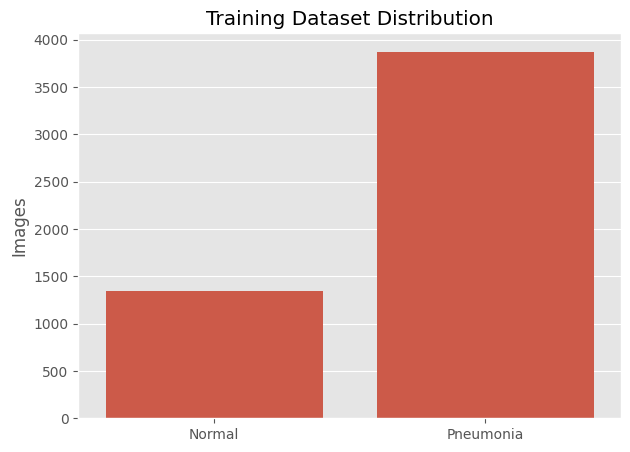

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(

x=["Normal","Pneumonia"],

y=[train_count["NORMAL"],train_count["PNEUMONIA"]]

)

plt.title("Training Dataset Distribution")

plt.ylabel("Images")

plt.show()

Pie Chart

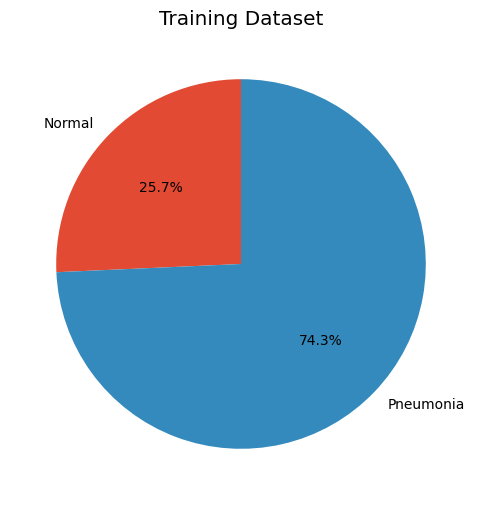

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(

[train_count["NORMAL"],train_count["PNEUMONIA"]],

labels=["Normal","Pneumonia"],

autopct="%1.1f%%",

startangle=90

)

plt.title("Training Dataset")

plt.show()

Show Random Images

In [ ]:
def show_random_images(folder,title):

    images = random.sample(os.listdir(folder),9)

    plt.figure(figsize=(12,12))

    for i,img in enumerate(images):

        image = cv2.imread(os.path.join(folder,img))

        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        plt.subplot(3,3,i+1)

        plt.imshow(image)

        plt.axis("off")

    plt.suptitle(title,fontsize=18)

    plt.show()

Display Normal Images

In [ ]:
show_random_images(
    os.path.join(train_path,"NORMAL"),
    "Normal Chest X-rays"
)

Display Pneumonia Images

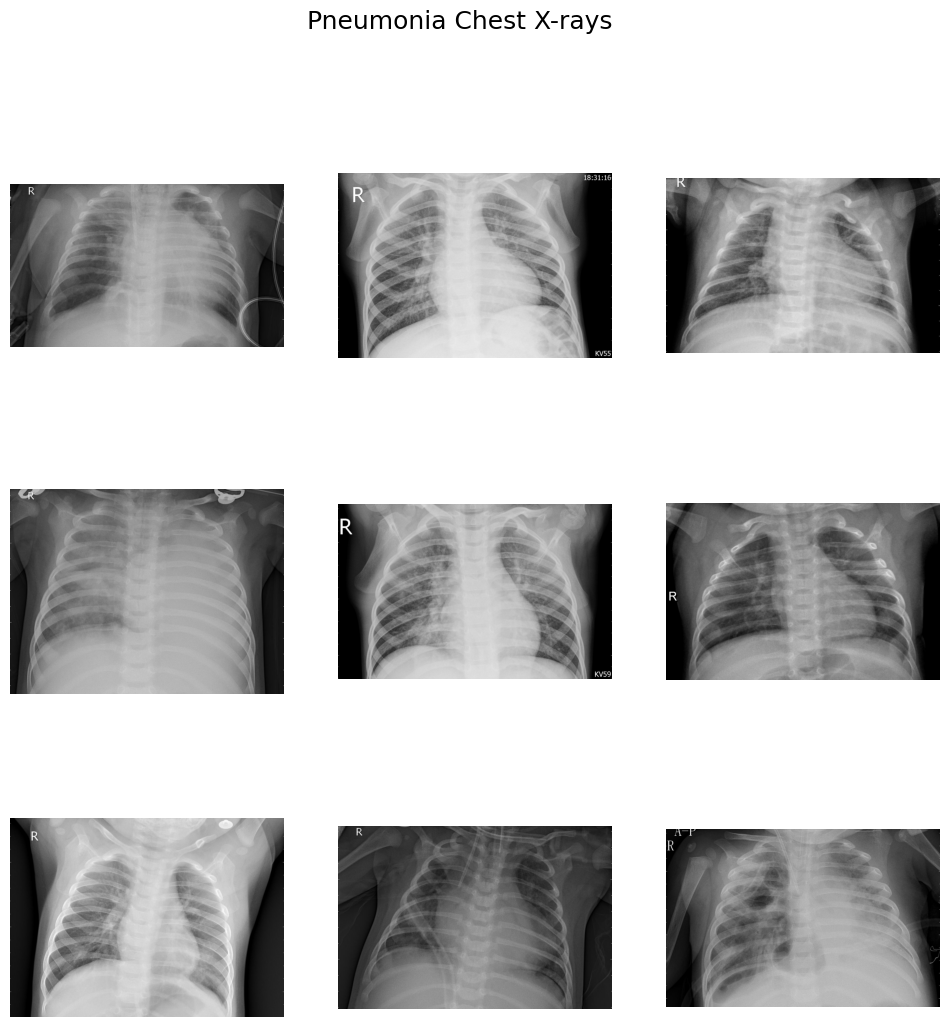

In [ ]:
show_random_images(
    os.path.join(train_path,"PNEUMONIA"),
    "Pneumonia Chest X-rays"
)

Image Resolution Analysis

In [ ]:
width=[]
height=[]

for cls in ["NORMAL","PNEUMONIA"]:

    folder=os.path.join(train_path,cls)

    for img in os.listdir(folder):

        image=cv2.imread(os.path.join(folder,img))

        h,w=image.shape[:2]

        width.append(w)
        height.append(h)

Resolution Statistics

In [ ]:
print("Average Width :",np.mean(width))
print("Average Height :",np.mean(height))

print("Maximum Width :",max(width))
print("Maximum Height :",max(height))

print("Minimum Width :",min(width))
print("Minimum Height :",min(height))

Average Width : 1320.6108128834355
Average Height : 968.0747699386503
Maximum Width : 2916
Maximum Height : 2663
Minimum Width : 384
Minimum Height : 127


Width Distribution

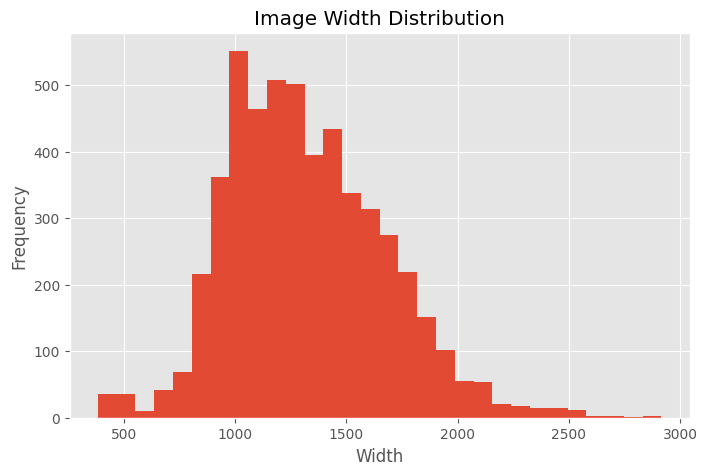

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(width,bins=30)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

Height Distribution

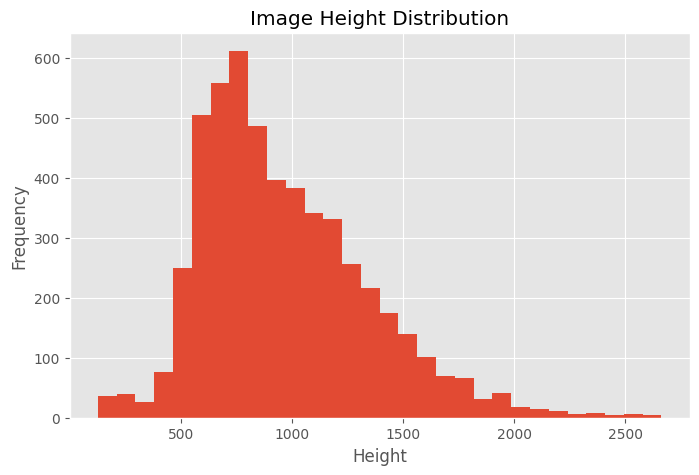

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(height,bins=30)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

Pixel Histogram

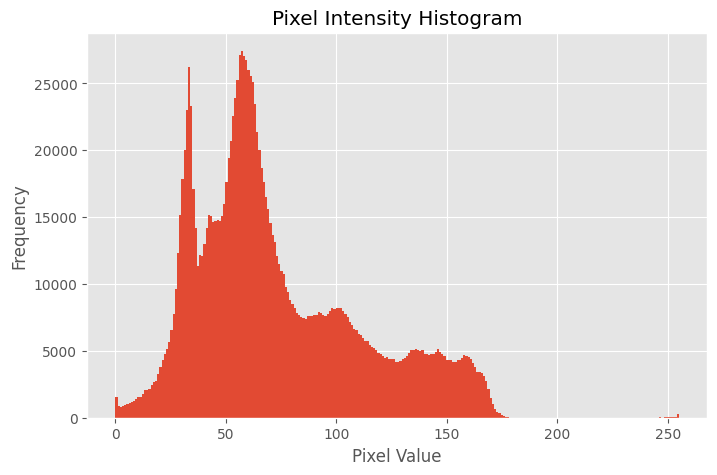

In [ ]:
image=cv2.imread(

os.path.join(

train_path,

"NORMAL",

os.listdir(os.path.join(train_path,"NORMAL"))[0]

),0)

plt.figure(figsize=(8,5))

plt.hist(image.ravel(),256)

plt.title("Pixel Intensity Histogram")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

Image Statistics

In [ ]:
print("Mean :",np.mean(image))

print("Standard Deviation :",np.std(image))

print("Minimum :",np.min(image))

print("Maximum :",np.max(image))

Mean : 73.29778275895019
Standard Deviation : 38.16525364706324
Minimum : 0
Maximum : 255


Check Corrupted Images

In [ ]:
corrupted=[]

for cls in ["NORMAL","PNEUMONIA"]:

    folder=os.path.join(train_path,cls)

    for img in os.listdir(folder):

        try:

            image=cv2.imread(os.path.join(folder,img))

            if image is None:

                corrupted.append(img)

        except:

            corrupted.append(img)

print("Corrupted Images :",len(corrupted))

Corrupted Images : 0


Duplicate Image Detection

In [ ]:
hashes={}

duplicates=[]

for cls in ["NORMAL","PNEUMONIA"]:

    folder=os.path.join(train_path,cls)

    for img in os.listdir(folder):

        path=os.path.join(folder,img)

        with open(path,"rb") as f:

            filehash=hashlib.md5(f.read()).hexdigest()

        if filehash in hashes:

            duplicates.append(img)

        else:

            hashes[filehash]=img

print("Duplicate Images :",len(duplicates))

Duplicate Images : 26


Dataset Information

In [ ]:
print("="*50)

print("TRAIN IMAGES")

print(train_count)

print("="*50)

print("VALIDATION IMAGES")

print(val_count)

print("="*50)

print("TEST IMAGES")

print(test_count)

print("="*50)

print("TOTAL IMAGES")

print(summary["Total"].sum())

TRAIN IMAGES
{'PNEUMONIA': 3875, 'NORMAL': 1341}
VALIDATION IMAGES
{'PNEUMONIA': 8, 'NORMAL': 8}
TEST IMAGES
{'PNEUMONIA': 390, 'NORMAL': 234}
TOTAL IMAGES
5856


Class Imbalance

In [ ]:
normal=train_count["NORMAL"]

pne=train_count["PNEUMONIA"]

print("Normal :",normal)

print("Pneumonia :",pne)

print("Ratio :",round(pne/normal,2))

Normal : 1341
Pneumonia : 3875
Ratio : 2.89


EDA Summary

In [ ]:
print("========== DATASET SUMMARY ==========")

print()

print("Total Images :",summary["Total"].sum())

print()

print("Training Images :",summary["Total"][0])

print()

print("Validation Images :",summary["Total"][1])

print()

print("Testing Images :",summary["Total"][2])

print()

print("Corrupted Images :",len(corrupted))

print()

print("Duplicate Images :",len(duplicates))

print()

print("Average Width :",round(np.mean(width),2))

print()

print("Average Height :",round(np.mean(height),2))

print()

print("Average Pixel Value :",round(np.mean(image),2))

========== DATASET SUMMARY ==========

Total Images : 5856

Training Images : 5216

Validation Images : 16

Testing Images : 624

Corrupted Images : 0

Duplicate Images : 26

Average Width : 1320.61

Average Height : 968.07

Average Pixel Value : 148.88
